In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

def test_dataset(df_o:pd.DataFrame, X_col:str, y_col:str):
    columns = [X_col, y_col]
    df = df_o[columns].dropna()

    X, y = np.asarray(df[[X_col]]), np.asarray(df[y_col])
    sns.scatterplot(data=df, y=y_col, x=X_col)
    
    data = {'X': X.reshape(1,-1)[0],'y': y}
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    model = LinearRegression().fit(X_train, y_train)
    print(model.score(X_test, y_test))


def score_function(y_true, y_pred_all):
    """Measures overall model quality on test set"""
    mse = np.mean((y_true - y_pred_all) ** 2)
    r2 = 1 - (mse / np.var(y_true))

    return r2

0.7651981388137586


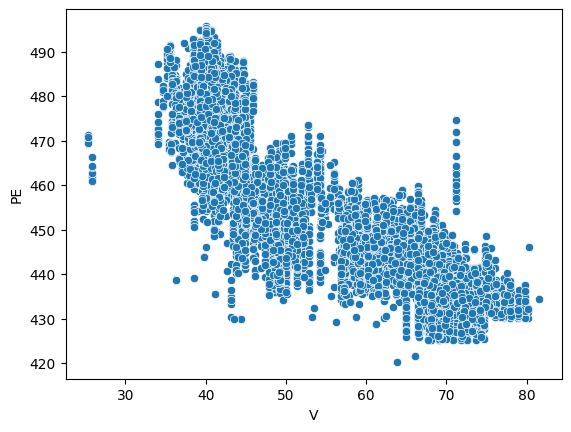

In [3]:
filepath='../data/combined+cycle+power+plant/CCPP/Folds5x2_pp.xlsx'
df_o = pd.read_excel(filepath)

X_col = 'V'
y_col = 'PE'
test_dataset(df_o, X_col, y_col)

In [4]:
from sklearn.model_selection import train_test_split

df = df_o[[X_col, y_col]].dropna()

X = np.asarray(df[[X_col]])
y = np.asarray(df[y_col])

data = {'X': X.reshape(1,-1)[0],'y': y}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

data_train = {'X': X_train.reshape(1,-1)[0],'y': y_train}
data_test = {'X': X_test.reshape(1,-1)[0],'y': y_test}

## Simple Linear Regression

0.7651981388137586
0.7651981388137586


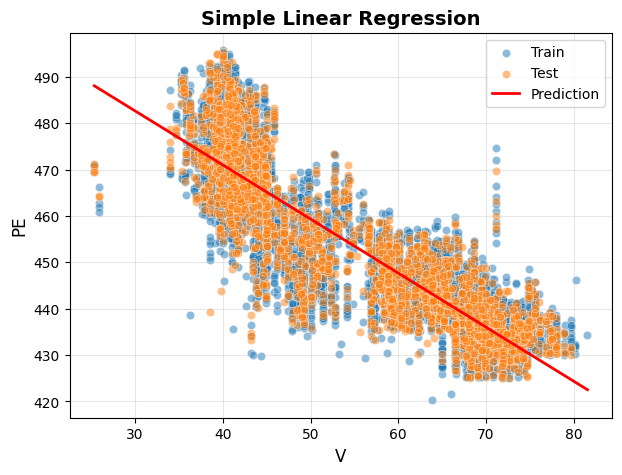

In [84]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)
print(model.score(X_test, y_test))
y_pred = model.predict(X_test)

print(score_function(y_test, y_pred))

y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Simple Linear Regression', name='simple_linear_regression.png')

## KNN

0.9036123689497036
0.9036123689497036


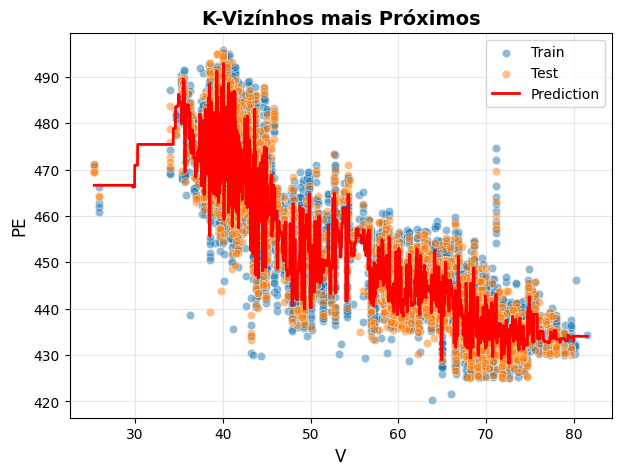

In [99]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regression
model = KNeighborsRegressor(n_neighbors=8)  # You can adjust k value
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))
print(score_function(y_test, y_pred))

y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='K-Vizínhos mais Próximos', name='knn.png')

## Kernel KNN

In [98]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import euclidean_distances

class KernelKNNRegressor(BaseEstimator, RegressorMixin):
    """
    KNN Regressor with kernel weighting functions.
    
    Parameters:
    -----------
    k : int, default=8
        Number of neighbors to consider
    kernel : str, default='gaussian'
        Type of kernel: 'cosine', 'epanechnikov', 'exponential', 'gaussian', 'triangular', 'uniform'
    """
    
    def __init__(self, k=8, kernel='gaussian'):
        self.k = k
        self.kernel = kernel
        
    def _kernel_function(self, u):
        """Apply the specified kernel function."""
        if self.kernel == 'cosine':
            return (np.pi/4) * np.cos((np.pi * u) / 2) * (np.abs(u) <= 1)
        elif self.kernel == 'epanechnikov':
            return (3/4) * (1 - u**2) * (np.abs(u) <= 1)
        elif self.kernel == 'exponential':
            return (1/2) * np.exp(-np.abs(u))
        elif self.kernel == 'gaussian':
            return np.exp(-u**2 / 2)
        elif self.kernel == 'triangular':
            return (1 - np.abs(u)) * (np.abs(u) <= 1)
        elif self.kernel == 'uniform':
            return (1/2) * (np.abs(u) <= 1)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
    
    def fit(self, X, y):
        """Store training data."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        """Predict using kernel-weighted KNN."""
        X = np.array(X)
        n_samples = X.shape[0]
        predictions = np.zeros(n_samples)
        
        for i in range(n_samples):
            distances = euclidean_distances(X[i:i+1], self.X_train)[0]
            k_nearest_idx = np.argsort(distances)[:self.k]
            k_distances = distances[k_nearest_idx]
            k_neighbors_y = self.y_train[k_nearest_idx]
            
            max_dist = np.max(k_distances)
            
            if max_dist == 0:
                weights = np.ones_like(k_distances)
            else:
                normalized_distances = k_distances / max_dist
                weights = self._kernel_function(normalized_distances)
                weights = np.maximum(weights, 0)
            
            if np.sum(weights) > 0:
                predictions[i] = np.sum(weights * k_neighbors_y) / np.sum(weights)
            else:
                predictions[i] = np.mean(k_neighbors_y)
                
        return predictions

In [114]:
results = []
kernels = ['cosine', 'epanechnikov', 'exponential', 'gaussian', 'triangular', 'uniform']
for kernel in kernels:
    for k in range(1, 100):
        model = KernelKNNRegressor(k=k, kernel=kernel)
        model.fit(X_train, y_train)
        # y_pred = model.predict(X_test)
        y_pred = model.predict(X_train)
        
        score = score_function(y_train, y_pred)
        result = {'k': k, 'kernel': kernel, 'score': score}
        results.append(result)
        print(k, kernel, score)

1 cosine 0.8478039969300937
2 cosine 0.8878676858239087
3 cosine 0.9022531415028608
4 cosine 0.9090141594241911
5 cosine 0.9123504890179923
6 cosine 0.9147965566575261
7 cosine 0.9172179147131343
8 cosine 0.918263130308422
9 cosine 0.918863370253647
10 cosine 0.9194382679272947
11 cosine 0.9194642629140455
12 cosine 0.9191343704091626
13 cosine 0.9194445610446464
14 cosine 0.9191812142772563
15 cosine 0.9187329249693702
16 cosine 0.918170020633315
17 cosine 0.9166541116644488
18 cosine 0.9141732559217902
19 cosine 0.9131049894360214
20 cosine 0.9115430324142451
21 cosine 0.9083770059689297
22 cosine 0.9064752270734505
23 cosine 0.9048984791602334
24 cosine 0.9032449186042439
25 cosine 0.8999432692339464
26 cosine 0.898616716389174
27 cosine 0.8955468990341219
28 cosine 0.8937407681840339
29 cosine 0.8913249249455122
30 cosine 0.8906424768362814
31 cosine 0.886714274839653
32 cosine 0.8847343982323937
33 cosine 0.8815947150142637
34 cosine 0.8805436889655767
35 cosine 0.8781970393004548

In [115]:
# Save results to CSV
dfr = pd.DataFrame(results)
dfr.to_csv('kernel_knn_regression_results.csv', index=False)

In [116]:
sorted(results, key=lambda x: x['score'], reverse=True)[:10]

[{'k': 13, 'kernel': 'triangular', 'score': np.float64(0.9200447133461027)},
 {'k': 14, 'kernel': 'triangular', 'score': np.float64(0.9198759600638438)},
 {'k': 11, 'kernel': 'triangular', 'score': np.float64(0.9198472296143168)},
 {'k': 12, 'kernel': 'triangular', 'score': np.float64(0.9196782745172576)},
 {'k': 10, 'kernel': 'triangular', 'score': np.float64(0.9196595484368875)},
 {'k': 15, 'kernel': 'triangular', 'score': np.float64(0.9196046605882849)},
 {'k': 11, 'kernel': 'cosine', 'score': np.float64(0.9194642629140455)},
 {'k': 13, 'kernel': 'cosine', 'score': np.float64(0.9194445610446464)},
 {'k': 10, 'kernel': 'cosine', 'score': np.float64(0.9194382679272947)},
 {'k': 10, 'kernel': 'epanechnikov', 'score': np.float64(0.9193851001854011)}]

0.9115083734852705


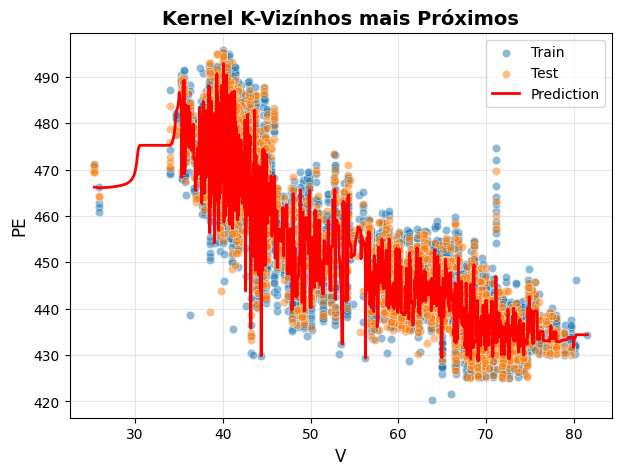

In [118]:
# Use Kernel KNN
model = KernelKNNRegressor(k=13, kernel='triangular')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(score_function(y_test, y_pred))

y_line = model.predict(X_line)
plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel K-Vizínhos mais Próximos', name='kernel_knn.png')

## Nadaraya-Watson

In [124]:
class NadarayaWatsonRegressor(BaseEstimator, RegressorMixin):    
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
    
    def _kernel_function(self, u):
        if self.kernel == 'cosine':
            return (np.pi/4) * np.cos((np.pi * u) / 2) * (np.abs(u) <= 1)
        elif self.kernel == 'epanechnikov':
            return (3/4) * (1 - u**2) * (np.abs(u) <= 1)
        elif self.kernel == 'exponential':
            return (1/2) * np.exp(-np.abs(u))
        elif self.kernel == 'gaussian':
            return np.exp(-u**2 / 2)
        elif self.kernel == 'triangular':
            return (1 - np.abs(u)) * (np.abs(u) <= 1)
        elif self.kernel == 'uniform':
            return (1/2) * (np.abs(u) <= 1)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self
    
    def predict(self, X):
        X = np.array(X)
        predictions = np.zeros(len(X))
        
        for i, x in enumerate(X):
            # Calculate distances to ALL training points
            distances = euclidean_distances([x], self.X_train)[0]
            
            # Apply kernel with bandwidth
            u = distances / self.bandwidth
            weights = self._kernel_function(u)/self.bandwidth
            
            # Nadaraya-Watson weighted average
            if np.sum(weights) > 0:
                predictions[i] = np.sum(weights * self.y_train) / np.sum(weights)
            else:
                predictions[i] = np.mean(self.y_train)
        
        return predictions

In [126]:
kernels = ['cosine', 'epanechnikov', 'exponential', 'gaussian', 'triangular', 'uniform']
for kernel in kernels:
    # for bandwidth in range(1, 10):
    for bandwidth in range(2, 10):
        model = NadarayaWatsonRegressor(bandwidth=bandwidth, kernel=kernel)
        model.fit(X_train, y_train)
        # y_pred = model.predict(X_test)
        y_pred = model.predict(X_train)
        
        score = score_function(y_train, y_pred)
        result = {'k': bandwidth, 'kernel': kernel, 'score': score}
        results.append(result)
        print(bandwidth, kernel, score)

2 cosine 0.8005472845595247
3 cosine 0.79832463354981
4 cosine 0.7946512316957576
5 cosine 0.7898138922761219
6 cosine 0.784390851022578
7 cosine 0.7780772303478654
8 cosine 0.7708211948508469
9 cosine 0.7628577853319434
2 epanechnikov 0.800337484026043
3 epanechnikov 0.7980218640157402
4 epanechnikov 0.7940666789299653
5 epanechnikov 0.7889118103358522
6 epanechnikov 0.7831754945961225
7 epanechnikov 0.7764609255375909
8 epanechnikov 0.768755672798267
9 epanechnikov 0.7603224548445824
2 exponential 0.7897561276180276
3 exponential 0.7783163403859646
4 exponential 0.7689672869278126
5 exponential 0.7606971339924826
6 exponential 0.7517613889665468
7 exponential 0.7410287522950227
8 exponential 0.7281247537944655
9 exponential 0.7131898477080247
2 gaussian 0.7931756298361431
3 gaussian 0.781498613015859
4 gaussian 0.7678598708332867
5 gaussian 0.75576144903403
6 gaussian 0.746316870019788
7 gaussian 0.7387077152527002
8 gaussian 0.7312195295495048
9 gaussian 0.7218573240875328
2 triangu

In [125]:
results = []
kernels = ['cosine', 'epanechnikov', 'exponential', 'gaussian', 'triangular', 'uniform']
for kernel in kernels:
    # for bandwidth in range(1, 10):
    for bandwidth in [1,10,100,1000]:
        model = NadarayaWatsonRegressor(bandwidth=bandwidth, kernel=kernel)
        model.fit(X_train, y_train)
        # y_pred = model.predict(X_test)
        y_pred = model.predict(X_train)
        
        score = score_function(y_train, y_pred)
        result = {'k': bandwidth, 'kernel': kernel, 'score': score}
        results.append(result)
        print(bandwidth, kernel, score)

1 cosine 0.804026776671749
10 cosine 0.7549245889804239
100 cosine 0.060261667100573235
1000 cosine 0.0005969910999168437
1 epanechnikov 0.8036068269539712
10 epanechnikov 0.7519977859540266
100 epanechnikov 0.04956409581485244
1000 epanechnikov 0.00048397099722230497
1 exponential 0.8012790049616283
10 exponential 0.6966208372634188
100 exponential 0.13976938214055157
1000 exponential 0.01475111938778606
1 gaussian 0.8006419770967951
10 gaussian 0.7089627846952096
100 gaussian 0.02390252904298229
1000 gaussian 0.00024189860660961404
1 triangular 0.8070454458986349
10 triangular 0.7626073433292315
100 triangular 0.16587074393337908
1000 triangular 0.014994948656608997
1 uniform 0.8002491050079575
10 uniform 0.7185467359526145
100 uniform 0.0
1000 uniform 0.0


In [127]:
sorted(results, key=lambda x: x['score'], reverse=True)[:10]

[{'k': 1, 'kernel': 'triangular', 'score': np.float64(0.8070454458986349)},
 {'k': 1, 'kernel': 'cosine', 'score': np.float64(0.804026776671749)},
 {'k': 1, 'kernel': 'epanechnikov', 'score': np.float64(0.8036068269539712)},
 {'k': 2, 'kernel': 'triangular', 'score': np.float64(0.8020654154433623)},
 {'k': 1, 'kernel': 'exponential', 'score': np.float64(0.8012790049616283)},
 {'k': 1, 'kernel': 'gaussian', 'score': np.float64(0.8006419770967951)},
 {'k': 2, 'kernel': 'cosine', 'score': np.float64(0.8005472845595247)},
 {'k': 2, 'kernel': 'epanechnikov', 'score': np.float64(0.800337484026043)},
 {'k': 1, 'kernel': 'uniform', 'score': np.float64(0.8002491050079575)},
 {'k': 3, 'kernel': 'triangular', 'score': np.float64(0.7995934356904293)}]

0.8140531379411667


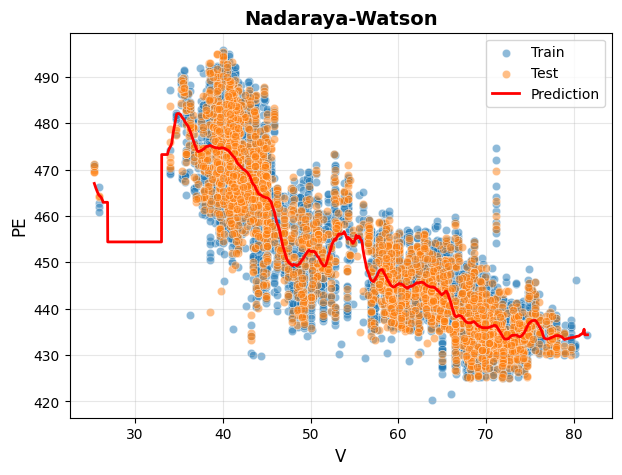

In [128]:
model = NadarayaWatsonRegressor(bandwidth=1, kernel='triangular')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(score_function(y_test, y_pred))

y_line = model.predict(X_line)
plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Nadaraya-Watson', name='nadaraya_watson.png')

In [45]:
from sklearn.neighbors import KernelDensity
import numpy as np

class NadarayaWatson:
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def _kernel_function(self, distances):
        if self.kernel == 'gaussian':
            return np.exp(-distances**2 / (2 * self.bandwidth**2))
        elif self.kernel == 'epanechnikov':
            weights = 0.75 * (1 - (distances/self.bandwidth)**2)
            weights[distances > self.bandwidth] = 0
            return weights
        else:  # uniform
            return (np.abs(distances) <= self.bandwidth).astype(float)
    
    def predict(self, X):
        predictions = []
        
        for x in X:
            # Compute distances to all training points
            distances = np.linalg.norm(self.X_train - x, axis=1)
            
            # Compute kernel weights
            weights = self._kernel_function(distances)
            
            # Avoid division by zero
            if weights.sum() == 0:
                weights = np.ones_like(weights)
            
            # Normalize weights
            weights = weights / weights.sum()
            
            # Weighted average
            pred = np.sum(weights * self.y_train)
            predictions.append(pred)
        
        return np.array(predictions)

# Usage
model = NadarayaWatson(bandwidth=1.0, kernel='gaussian')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# print(model.score(X_test, y_test))
print(score_function(y_test, y_pred))

0.8097111736403658


## Ridge Regression

In [81]:
step = 0.01
X_min, X_max = 25.36, 81.56
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)

def plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title=None, name=None):
    plt.figure(figsize=(7, 5))

    default_colors = sns.color_palette()
    seaborn_blue = default_colors[0]  # First color in palette
    seaborn_orange = default_colors[1]  # Second color in palette
    
    # Seaborn scatterplots
    sns.scatterplot(x=X_train.flatten(), y=y_train, alpha=0.5, label='Train', color=seaborn_blue)
    sns.scatterplot(x=X_test.flatten(), y=y_test, alpha=0.5, label='Test', color=seaborn_orange)
    
    # Predicted line (matplotlib is fine for lines)
    plt.plot(X_line, y_line, 'r-', linewidth=2, label='Prediction')
    
    plt.xlabel('V', fontsize=12)
    plt.ylabel('PE', fontsize=12)
    plt.legend(fontsize=10)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.savefig(name)
    plt.show()

In [90]:
alphas = [0.00001, 0.0001, 0.001,0.01,0.1,1,10,100,1000,10000]
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    print(alpha, model.score(X_train, y_train))    

1e-05 0.7527461826467723
0.0001 0.7527461826467725
0.001 0.7527461826467724
0.01 0.7527461826467724
0.1 0.7527461826467661
1 0.7527461826461225
10 0.7527461825817795
100 0.7527461761485638
1000 0.7527455339113146
10000 0.7526823797156367


0.7527461826461225
0.7651981318966635


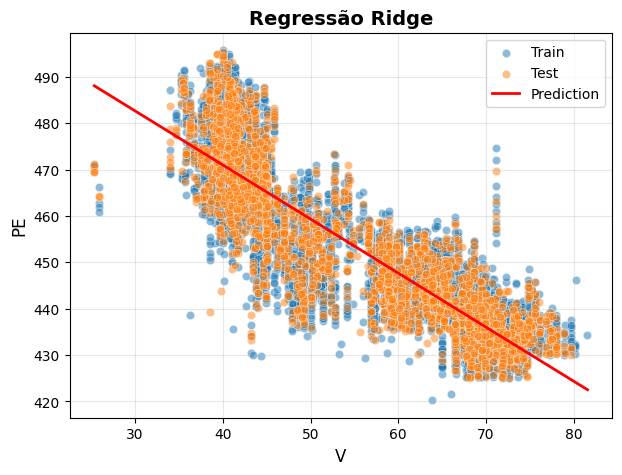

In [97]:
from sklearn.linear_model import Ridge

# Ridge Regression
model = Ridge(alpha=1)  # alpha is the regularization strength
model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))


y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Regressão Ridge', name='ridge_regression.png')

In [73]:
import matplotlib.pyplot as plt


## Kernel Ridge Regression

In [132]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import euclidean_distances

class KernelRidgeRegression(BaseEstimator, RegressorMixin):
    """
    Kernel Ridge Regression with different kernel functions.
    
    Parameters:
    -----------
    alpha : float, default=1.0
        Regularization strength (lambda)
    kernel : str, default='gaussian'
        Type of kernel: 'linear', 'polynomial2', 'polynomial3', 'gaussian', 'laplacian', 'sigmoidal'
    c : float, default=1.0
        Constant parameter for polynomial and sigmoidal kernels
    gamma : float, default=1.0
        Gamma parameter for RBF kernels (gaussian, laplacian)
    alpha_sigmoid : float, default=1.0
        Alpha parameter for sigmoidal kernel
    """
    
    def __init__(self, alpha=1.0, kernel='gaussian', c=1.0, gamma=1.0, alpha_sigmoid=1.0):
        self.alpha = alpha  # regularization strength (lambda)
        self.kernel = kernel
        self.c = c
        self.gamma = gamma
        self.alpha_sigmoid = alpha_sigmoid
    
    def _kernel_matrix(self, X, Y=None):
        """Compute kernel matrix K(X, Y)."""
        if Y is None:
            Y = X
        
        if self.kernel == 'linear':
            # K(x, y) = x^T y
            return X @ Y.T
        
        elif self.kernel == 'polynomial2':
            # K(x, y) = (x^T y + c)^2
            return (X @ Y.T + self.c) ** 2
        
        elif self.kernel == 'polynomial3':
            # K(x, y) = (x^T y + c)^3
            return (X @ Y.T + self.c) ** 3
        
        elif self.kernel == 'gaussian':
            # K(x, y) = exp(-γ ||x - y||^2)
            dist_matrix = euclidean_distances(X, Y, squared=True)
            return np.exp(-self.gamma * dist_matrix)
        
        elif self.kernel == 'laplacian':
            # K(x, y) = exp(-γ ||x - y||)
            dist_matrix = euclidean_distances(X, Y)
            return np.exp(-self.gamma * dist_matrix)
        
        elif self.kernel == 'sigmoidal':
            # K(x, y) = tanh(α x^T y + c)
            return np.tanh(self.alpha_sigmoid * (X @ Y.T) + self.c)
        
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
    
    def fit(self, X, y):
        """
        Fit Kernel Ridge Regression model.
        
        Solves: min_{β} ||y - Kβ||^2 + α β^T K β
        Solution: β = (K + αI)^{-1} y
        """
        X = np.array(X)
        y = np.array(y)
        
        self.X_train = X
        
        # Compute kernel matrix K
        K = self._kernel_matrix(X)
        
        # Add regularization: (K + αI)
        n = K.shape[0]
        K_reg = K + self.alpha * np.eye(n)
        
        # Solve for coefficients β
        self.beta = np.linalg.solve(K_reg, y)
        
        return self
    
    def predict(self, X):
        """Predict using the kernel model."""
        X = np.array(X)
        
        # Compute kernel between test and training points
        K_test = self._kernel_matrix(X, self.X_train)
        
        # Prediction: f(x) = Σ β_i K(x, x_i)
        return K_test @ self.beta

In [143]:
alpha_values =  [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
gamma_values = [0.01, 0.05, 0.1, 0.5,1.0]

results = []
for kernel_name in ['gaussian', 'laplacian']:
    for alpha in alpha_values:
        for gamma in gamma_values:
            model = KernelRidgeRegression(kernel=kernel_name, alpha=alpha, gamma=gamma)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_train)        
            score = r2_score(y_train, y_pred)
            result = {'kernel': kernel_name, 'score': score, 'alpha': alpha, 'gamma': gamma}
            results.append(result)
            print(result)

{'kernel': 'gaussian', 'score': 0.7986459969679266, 'alpha': 0.001, 'gamma': 0.01}
{'kernel': 'gaussian', 'score': 0.8023105681041949, 'alpha': 0.001, 'gamma': 0.05}
{'kernel': 'gaussian', 'score': 0.8033221043914909, 'alpha': 0.001, 'gamma': 0.1}
{'kernel': 'gaussian', 'score': 0.8097957153890855, 'alpha': 0.001, 'gamma': 0.5}
{'kernel': 'gaussian', 'score': 0.8156113347869283, 'alpha': 0.001, 'gamma': 1.0}
{'kernel': 'gaussian', 'score': 0.7984530387802458, 'alpha': 0.005, 'gamma': 0.01}
{'kernel': 'gaussian', 'score': 0.8019716753339634, 'alpha': 0.005, 'gamma': 0.05}
{'kernel': 'gaussian', 'score': 0.8029920296606361, 'alpha': 0.005, 'gamma': 0.1}
{'kernel': 'gaussian', 'score': 0.8090022148311767, 'alpha': 0.005, 'gamma': 0.5}
{'kernel': 'gaussian', 'score': 0.8141998595113537, 'alpha': 0.005, 'gamma': 1.0}
{'kernel': 'gaussian', 'score': 0.7983328294065843, 'alpha': 0.01, 'gamma': 0.01}
{'kernel': 'gaussian', 'score': 0.8017738235829222, 'alpha': 0.01, 'gamma': 0.05}
{'kernel': '

In [144]:
sorted(results, key=lambda x: x['score'], reverse=True)[:10]

[{'kernel': 'laplacian',
  'score': 0.9230813549925523,
  'alpha': 0.001,
  'gamma': 1.0},
 {'kernel': 'laplacian',
  'score': 0.9230609333262141,
  'alpha': 0.001,
  'gamma': 0.5},
 {'kernel': 'laplacian',
  'score': 0.9229356530808759,
  'alpha': 0.005,
  'gamma': 1.0},
 {'kernel': 'laplacian',
  'score': 0.9225870833742047,
  'alpha': 0.001,
  'gamma': 0.1},
 {'kernel': 'laplacian',
  'score': 0.9225862740291338,
  'alpha': 0.005,
  'gamma': 0.5},
 {'kernel': 'laplacian',
  'score': 0.9225781994973841,
  'alpha': 0.01,
  'gamma': 1.0},
 {'kernel': 'laplacian',
  'score': 0.9215797296246829,
  'alpha': 0.001,
  'gamma': 0.05},
 {'kernel': 'laplacian',
  'score': 0.9215749451526823,
  'alpha': 0.01,
  'gamma': 0.5},
 {'kernel': 'laplacian',
  'score': 0.9177548972624776,
  'alpha': 0.005,
  'gamma': 0.1},
 {'kernel': 'laplacian',
  'score': 0.9174775809075119,
  'alpha': 0.05,
  'gamma': 1.0}]

In [139]:
# Define hyperparameter grids
param_grids = {
    'linear': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]},
    'polynomial2': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'c': [0, 0.5, 1.0, 2.0]},
    'polynomial3': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'c': [0, 0.5, 1.0, 2.0]},
    'gaussian': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'gamma': [0.01, 0.1, 1.0, 10.0]},
    'laplacian': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'gamma': [0.01, 0.1, 1.0, 10.0]},
    'sigmoidal': {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'alpha_sigmoid': [0.001, 0.01, 0.1, 1.0], 'c': [-1, 0, 1]}
}

# Results list
results = []

print("Kernel Ridge Regression - Hyperparameter Testing")
print("=" * 70)

# Test each kernel
for kernel_name in param_grids:
    print(f"\nTesting {kernel_name}...")
    
    # Get parameter grid for this kernel
    param_grid = param_grids[kernel_name]
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    
    # Generate all combinations
    from itertools import product
    for combo in product(*param_values):
        params = dict(zip(param_names, combo))
        
        # Create and train model
        model = KernelRidgeRegression(kernel=kernel_name, **params)
        
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_train)
            r2 = r2_score(y_train, y_pred)
            
            # Store result
            result = {'kernel': kernel_name, 'r2': r2, **params}
            results.append(result)
            
            print(f"  {params} -> R²: {r2:.4f}")
            
        except Exception as e:
            result = {'kernel': kernel_name, 'r2': -np.inf, **params, 'error': str(e)}
            results.append(result)
            print(f"  {params} -> FAILED")

Kernel Ridge Regression - Hyperparameter Testing

Testing linear...
  {'alpha': 0.0001} -> R²: -47.0058
  {'alpha': 0.001} -> R²: -47.0058
  {'alpha': 0.01} -> R²: -47.0058
  {'alpha': 0.1} -> R²: -47.0058
  {'alpha': 1.0} -> R²: -47.0058
  {'alpha': 10.0} -> R²: -47.0058

Testing polynomial2...
  {'alpha': 0.0001, 'c': 0} -> R²: -137.6019
  {'alpha': 0.0001, 'c': 0.5} -> R²: 0.7780
  {'alpha': 0.0001, 'c': 1.0} -> R²: 0.7780
  {'alpha': 0.0001, 'c': 2.0} -> R²: 0.7780
  {'alpha': 0.001, 'c': 0} -> R²: -137.6478
  {'alpha': 0.001, 'c': 0.5} -> R²: 0.7776
  {'alpha': 0.001, 'c': 1.0} -> R²: 0.7776
  {'alpha': 0.001, 'c': 2.0} -> R²: 0.7776
  {'alpha': 0.01, 'c': 0} -> R²: -137.6435
  {'alpha': 0.01, 'c': 0.5} -> R²: 0.7779
  {'alpha': 0.01, 'c': 1.0} -> R²: 0.7777
  {'alpha': 0.01, 'c': 2.0} -> R²: 0.7776
  {'alpha': 0.1, 'c': 0} -> R²: -137.6412
  {'alpha': 0.1, 'c': 0.5} -> R²: 0.7782
  {'alpha': 0.1, 'c': 1.0} -> R²: 0.7783
  {'alpha': 0.1, 'c': 2.0} -> R²: 0.7778
  {'alpha': 1.0, 'c

In [138]:
from sklearn.metrics import r2_score

# Test different kernels
kernels = ['linear', 'polynomial2', 'polynomial3', 'gaussian', 'laplacian', 'sigmoidal']

print("Kernel Ridge Regression Results:")

results = []
result  = {'score': None, 'kernel': None, 'alpha': None, 'c': None, 'gamma': gamma, 'alpha_sigmoid': alpha_sigmoid}
for kernel_name in kernels:
    # Configure hyperparameters based on kernel
    if kernel_name == 'polynomial2':
        model = KernelRidgeRegression(alpha=0.001, kernel=kernel_name, c=1.0)
    elif kernel_name == 'polynomial3':
        model = KernelRidgeRegression(alpha=0.001, kernel=kernel_name, c=1.0)
    elif kernel_name == 'gaussian':
        model = KernelRidgeRegression(alpha=0.001, kernel=kernel_name, gamma=0.1)
    elif kernel_name == 'laplacian':
        model = KernelRidgeRegression(alpha=0.001, kernel=kernel_name, gamma=0.1)
    elif kernel_name == 'sigmoidal':
        model = KernelRidgeRegression(alpha=0.001, kernel=kernel_name, alpha_sigmoid=0.01, c=0)
    else:  # linear
        model = KernelRidgeRegression(alpha=0.001, kernel=kernel_name)

    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)
    
    print(f"{kernel_name:12s}, R²: {r2:.4f}")

Kernel Ridge Regression Results:
linear      , R²: -47.0058
polynomial2 , R²: 0.7776
polynomial3 , R²: -54.9807
gaussian    , R²: 0.8113
laplacian   , R²: 0.9150
sigmoidal   , R²: -0.0002


0.9151052172496149


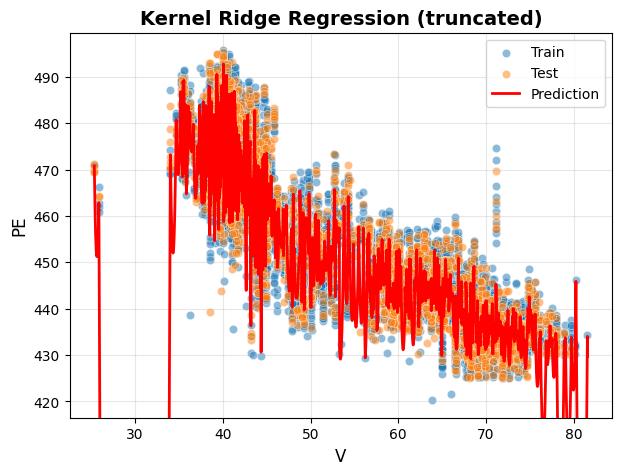

In [152]:
def plot_predictions_with_min(X_line, y_line, X_train, y_train, X_test, y_test, title=None, name=None):
    plt.figure(figsize=(7, 5))
    
    default_colors = sns.color_palette()
    seaborn_blue = default_colors[0]
    seaborn_orange = default_colors[1]
    
    # Seaborn scatterplots
    sns.scatterplot(x=X_train.flatten(), y=y_train, alpha=0.5, label='Train', color=seaborn_blue)
    sns.scatterplot(x=X_test.flatten(), y=y_test, alpha=0.5, label='Test', color=seaborn_orange)
    
    # Predicted line
    plt.plot(X_line, y_line, 'r-', linewidth=2, label='Prediction')
    
    # Set y-axis limits based ONLY on actual data (train + test), not predictions
    y_min = min(y_train.min(), y_test.min())  # Exclude y_line!
    y_max = max(y_train.max(), y_test.max())
    y_padding = (y_max - y_min) * 0.05  # Small padding (5%)
    plt.ylim(y_min - y_padding, y_max + y_padding)
    
    plt.xlabel('V', fontsize=12)
    plt.ylabel('PE', fontsize=12)
    plt.legend(fontsize=10)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.savefig(name)
    plt.show()

model = KernelRidgeRegression(alpha=0.001, kernel='laplacian', gamma=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(score_function(y_test, y_pred))

y_line = model.predict(X_line)
# plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel Ridge Regression', name='kerne_ridge.png')

plot_predictions_with_min(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel Ridge Regression (truncated)', name='kerne_ridge_trunc.png')

0.9151052172496149


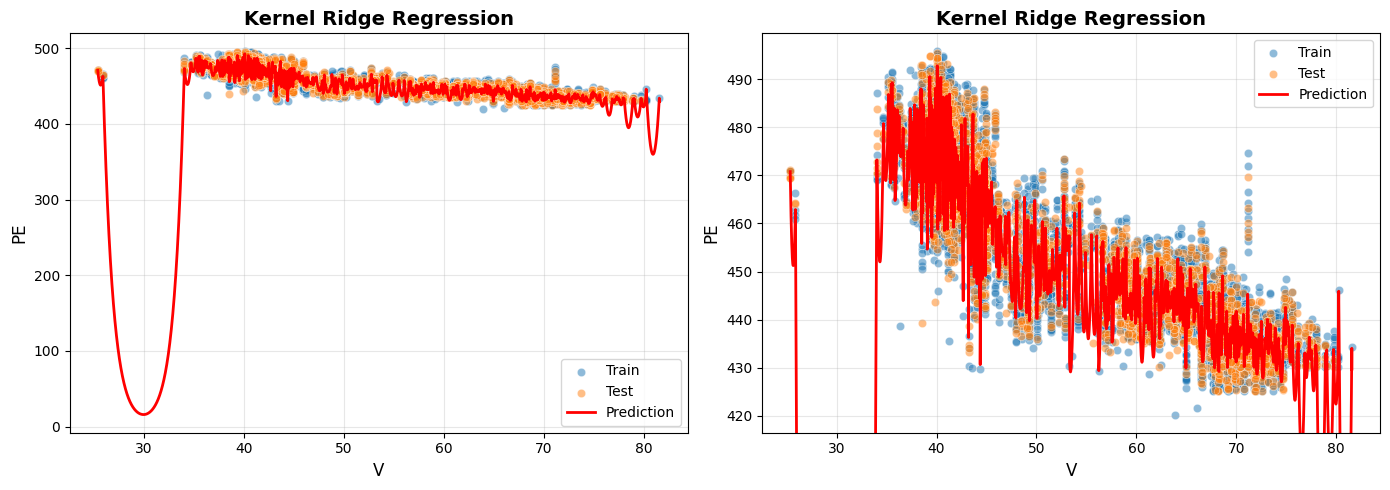

In [154]:
def plot_predictions_with_min(X_line, y_line, X_train, y_train, X_test, y_test, title=None, name=None):
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    default_colors = sns.color_palette()
    seaborn_blue = default_colors[0]
    seaborn_orange = default_colors[1]
    
    # Create dataframes for seaborn
    train_df = pd.DataFrame({'V': X_train.flatten(), 'PE': y_train})
    test_df = pd.DataFrame({'V': X_test.flatten(), 'PE': y_test})
    
    # ===== LEFT PLOT: Full view (including all prediction values) =====
    sns.scatterplot(data=train_df, x='V', y='PE', ax=axes[0], color=seaborn_blue, alpha=0.5, label='Train')
    sns.scatterplot(data=test_df, x='V', y='PE', ax=axes[0], color=seaborn_orange, alpha=0.5, label='Test')
    axes[0].plot(X_line, y_line, 'r-', linewidth=2, label='Prediction')
    axes[0].set_xlabel('V', fontsize=12)
    axes[0].set_ylabel('PE', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].set_title(f'{title}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # ===== RIGHT PLOT: Truncated view (capped to observed PE range) =====
    sns.scatterplot(data=train_df, x='V', y='PE', ax=axes[1], color=seaborn_blue, alpha=0.5, label='Train')
    sns.scatterplot(data=test_df, x='V', y='PE', ax=axes[1], color=seaborn_orange, alpha=0.5, label='Test')
    axes[1].plot(X_line, y_line, 'r-', linewidth=2, label='Prediction')
    
    # Set y-axis limits based ONLY on actual data (truncated)
    y_min = min(y_train.min(), y_test.min())
    y_max = max(y_train.max(), y_test.max())
    y_padding = (y_max - y_min) * 0.05
    axes[1].set_ylim(y_min - y_padding, y_max + y_padding)
    
    axes[1].set_xlabel('V', fontsize=12)
    axes[1].set_ylabel('PE', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].set_title(f'{title}', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Adjust layout and save
    plt.tight_layout()
    if name:
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

model = KernelRidgeRegression(alpha=0.001, kernel='laplacian', gamma=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(score_function(y_test, y_pred))

y_line = model.predict(X_line)

plot_predictions_with_min(X_line, y_line, X_train, y_train, X_test, y_test, title='Kernel Ridge Regression', name='kerne_ridge.png')    

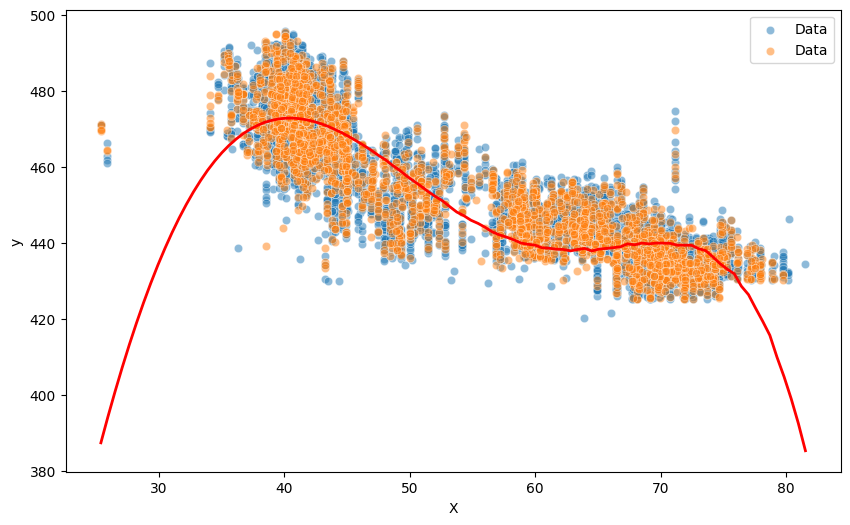

In [62]:
import matplotlib.pyplot as plt

# Generate curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_pred = model.predict(X_range)

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_train, x='X', y='y', alpha=0.5, label='Data')
sns.scatterplot(data=data_test, x='X', y='y', alpha=0.5, label='Data')
plt.plot(X_range, y_pred, color='red', linewidth=2)
plt.show()